# Duration Times Spread

*Dts (Duration Times Spread): A new measure of spread exposure in credit portfolios*, Arik Ben Dor, Lev Dynkin, Jay Hyman, Patrick Houweling,
Erik van Leeuwen, and Olaf Penninga

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score

# Path Management and Global Variables

In [2]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
data_path = os.path.join(repo_path, "data")

In [3]:
vol_renamer_ = {
    "abs_vol": r"$D \sigma_{abs}$",
    "rel_vol": r"$D s \sigma_{res}$"}

endog_renamer = {
    "alpha_j"  : r"$\alpha_J$",
    "count_val": r"$n$",	
    "t_stat"   : r"$t$-stat",	
    "r2"       : r"$R^2$"}

renamer = {**vol_renamer_, **endog_renamer}

# Examining Data

Start by examining the OAS of the data, for now we are going to use US-only data. 

In [4]:
path       = os.path.join(data_path, "CreditTickers.xlsx")
df_tickers = (pd
    .read_excel(io = path)
    .loc[lambda x: (x.region == "US") & (x.credit_type == "credit")])

tickers = (df_tickers
    .ticker
    .drop_duplicates()
    .sort_values()
    .to_list())

In [5]:
path   = os.path.join(data_path, "CreditData.parquet")
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .loc[lambda x: x.security.isin(tickers)]
    .assign(security = lambda x: x.security.str.split(" ").str[0]))

In [6]:
start_date = (df_raw
    .pivot(index = "date", columns = "security", values = "oas")
    .reset_index()
    [["date"]]
    .assign(
        lag_date    = lambda x: x.date.shift(),
        spread_date = lambda x: (x.date - x.lag_date).dt.days)
    .loc[lambda x: x.spread_date <= 4]
    .date
    .iloc[0])

In [7]:
df_sliced = (df_raw
    .loc[lambda x: x.date >= start_date])

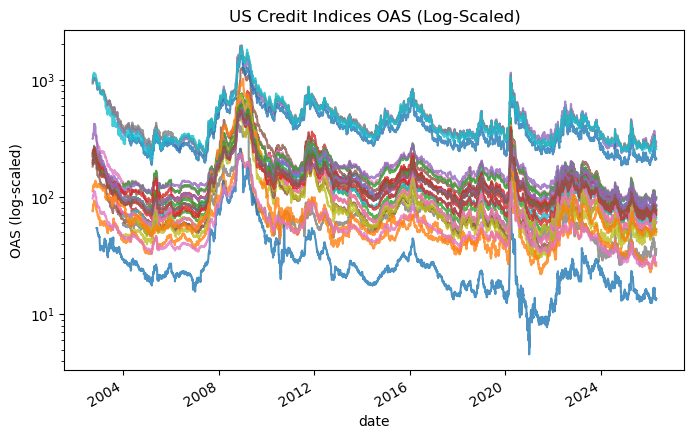

In [8]:
(df_sliced
    .loc[lambda x: x.oas != 0]
    .pivot(index = "date", columns = "security", values = "oas")
    .plot(
        figsize = (8,5),
        legend  = False,
        alpha   = 0.8,  
        logy    = True,
        ylabel  = "OAS (log-scaled)",
        title   = "US Credit Indices OAS (Log-Scaled)"))

plt.show()

# Model

Start with the two methodologies for modelling returns through the lens of duration and spread changes. Then we can calculate their respective volatility
\begin{align}
R_{spread} = 
\begin{cases}
\ -D\Delta s, & \text{Absolute} \\
\ - Ds \frac{\Delta s}{s}, & \text{Relative}
\end{cases}
\rightarrow
\sigma_{return} =
\begin{cases}
\ D \sigma_{absolute}, & \text{Absolute} \\
\ Ds \sigma_{relative}, & \text{Relative}
\end{cases}
\end{align}

In [9]:
df_oas = (df_sliced
    [["date", "security", "oas"]]
    .set_index("date"))

In [10]:
df_oas_diff = (df_oas
    .groupby(["security"])
    .apply(lambda x: x.sort_index().oas.diff())
    .to_frame(name = "oas_diff")
    .reset_index())

In [11]:
df_lag_oas = (df_oas
    .groupby("security")
    .apply(lambda x: x.sort_index().oas.shift())
    .to_frame(name = "lag_oas")
    .reset_index())

In [12]:
df_oas_prep = (df_oas_diff
    .merge(right = df_lag_oas, how = "inner", on = ["security", "date"])
    .assign(rel_diff = lambda x: x.oas_diff / x.lag_oas)
    .rename(columns = {"oas_diff": "abs_diff"})
    [["date", "security", "abs_diff", "rel_diff"]]
    .dropna())

In [13]:
num_months = 3

df_oas_tmp_vol = (df_oas_prep
    .set_index("date")
    .groupby("security")
    .apply(lambda x: x.sort_index().rolling(window = 30 * num_months).std())
    .reset_index()
    .dropna())

In [14]:
df_vol = (df_sliced
    [["date", "security", "sprd_dur", "oas"]]
    .merge(right = df_oas_tmp_vol, how = "inner", on = ["date", "security"])
    .assign(
        abs_vol = lambda x: x.abs_diff * x.sprd_dur,
        rel_vol = lambda x: x.rel_diff * x.oas * x.sprd_dur))

In [15]:
ticker_map = (df_tickers
    .dropna()
    .assign(
        ticker  = lambda x: x.ticker.str.split(" ").str[0],
        str_len = lambda x: x.plot_name.str.len())
    .loc[lambda x: x.str_len <= 4]
    .set_index("ticker")
    .plot_name
    .to_dict())

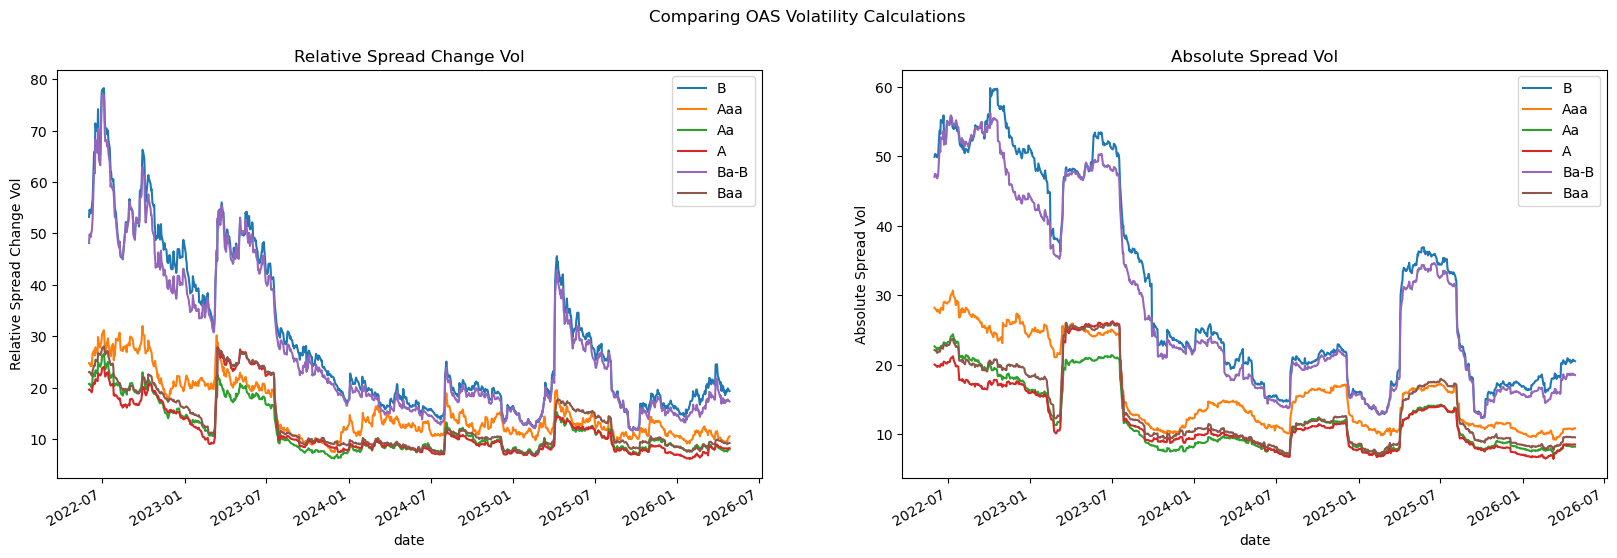

In [16]:
vol_dict  = {
    "rel_vol": "Relative Spread Change Vol", 
    "abs_vol": "Absolute Spread Vol"}

fig, axes = plt.subplots(ncols = len(vol_dict.keys()), figsize = (20,6))

for vol, ax in zip(vol_dict.keys(), axes.flatten()): 

    (df_vol
        .loc[lambda x: x.security.isin(list(ticker_map.keys()))]
        .rename(columns = {"security": ""})
        .pivot(index = "date", columns = "", values = vol)
        .rename(columns = ticker_map)
        .dropna()
        .tail(1_000)
        .plot(
            ax     = ax,
            ylabel = vol_dict[vol],
            title  = vol_dict[vol]))

fig.suptitle("Comparing OAS Volatility Calculations")
plt.show()

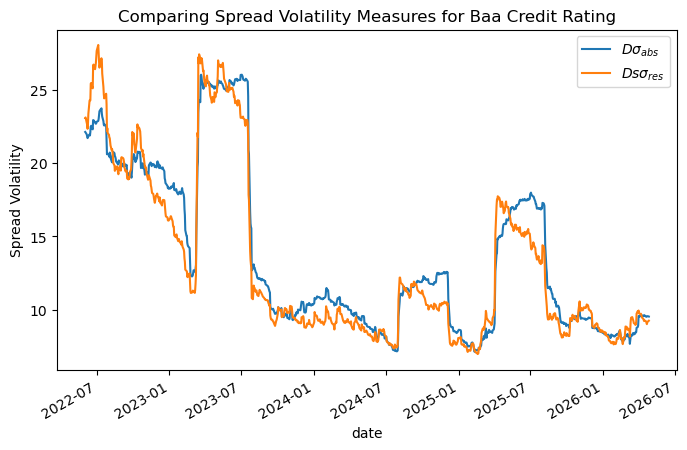

In [17]:
(df_vol
    .loc[lambda x: x.security == "LCB1TRUU"]
    .set_index("date")
    [["abs_vol", "rel_vol"]]
    .rename(columns = renamer)
    .tail(1_000)
    .plot(
        figsize = (8,5),
        ylabel  = "Spread Volatility",
        title   = "Comparing Spread Volatility Measures for Baa Credit Rating"))

plt.show()

# Dynamics of Spread Change

In [18]:
df_oas_diff = (df_oas
    .groupby("security")
    .apply(lambda x: x.sort_index().oas.diff())
    .to_frame(name = "oas_diff")
    .reset_index()
    .dropna())

In [19]:
df_oas_sys = (df_oas_diff
    .drop(columns = ["security"])
    .groupby("date")
    .agg("mean")
    .rename(columns = {"oas_diff": "oas_sys"})
    .reset_index())

They first start by modelling spread changes $\Delta s$ through a combination of a systemic $J$ component and idiosyncratic portion. In this case since index level data is being used an avearege of all of the OAS will be used. In the paper they use single name bonds (CUSIPs) and use the index value.
\begin{align}
\Delta s_{i,t} = \Delta s_{J,t} + \Delta s_{i,t}^{idio} \rightarrow \Delta s_{i,t} = \alpha_{J,t} + \epsilon_{i,t}
\end{align}

In [20]:
df_model1 = (df_oas_diff
    .merge(right = df_oas_sys, how = "inner", on = ["date"])
    .assign(resid = lambda x: x.oas_diff - x.oas_sys))

In [21]:
df_r2 = (
    1
    - df_model1.resid.pow(2).sum()
    / (
        df_model1.oas_diff
        .sub(df_model1.oas_diff.mean())
        .pow(2)
        .sum()))

In [22]:
def _get_r2(df: pd.DataFrame) -> pd.DataFrame:
    return r2_score(df.oas_diff, df.oas_sys)

df_r2 = (df_model1
    .groupby("security")
    .apply(_get_r2)
    .to_frame(name = "r2"))

In [23]:
df_model1_stats = (df_model1
    .groupby("security")
    .agg(
        alpha_j   = ("oas_sys", "mean"),
        std_val   = ("resid",   "std"),
        count_val = ("resid",   "count"))
    .assign(
        se     = lambda x: x.std_val / np.sqrt(x.count_val),
        t_stat = lambda x: x.alpha_j / x.se)
    .merge(right = df_r2, how = "inner", on = ["security"]))

In [24]:
(df_model1_stats
    .drop(columns = ["std_val", "se"])
    .rename(columns = renamer))

,$\alpha_J$,$n$,$t$-stat,$R^2$
security,,,,
BCR5TRUU,-0.056458,4299,-0.983986,0.418503
BUC1TRUU,-0.019519,5659,-0.799117,0.680943
BUS3TRUU,-0.011227,5134,-0.455859,0.698326
I00159US,-0.045490,5935,-1.637165,0.646668
I00185US,-0.045490,5935,-0.397011,0.399366
I00689US,-0.045490,5935,-0.681147,0.179536
I05746US,-0.049391,5892,-2.444672,0.742590
I08218US,-0.017556,5634,-0.284920,0.095165
I08219US,-0.017556,5634,-0.596276,0.308512


Then for the second model we will consider
\begin{align}
\frac{\Delta s_i}{s_i} &= \frac{\Delta s_J}{s_J} + \frac{\Delta s_i^{idio}}{s_i} \\
\Delta s_i             &= s_i \left(\frac{\Delta s_J}{s_J} \right) + \Delta s_i^{idio} \\
                       &\downarrow \\
\Delta s_{i,t}         &= \alpha_{J,t} + \beta_{J,t} \cdot s_{i,t} + \epsilon_{i,t}
\end{align}

In [25]:
(df_oas_diff)

,security,date,oas_diff
1,BCR5TRUU,2002-10-31,9.298562
2,BCR5TRUU,2002-11-29,-53.024656
3,BCR5TRUU,2002-12-31,-5.068479
4,BCR5TRUU,2003-01-31,-17.314111
5,BCR5TRUU,2003-02-28,-1.024170
...,...,...,...
155342,LUGCTRUU,2026-04-21,-0.175400
155343,LUGCTRUU,2026-04-22,-0.669800
155344,LUGCTRUU,2026-04-23,0.657000
155345,LUGCTRUU,2026-04-24,-0.203900


In [30]:
df_monthly = (df_oas
    .groupby("security")
    .resample("1ME")
    .first()
    .reset_index())

In [31]:
df_spread_vol = (df_monthly
    .set_index("date")
    .groupby("security")
    .apply(lambda x: x.oas.diff())
    .reset_index()
    .drop(columns = ["date"])
    .groupby("security")
    .agg("std")
    .rename(columns = {"oas": "spread_vol"}))

In [32]:
df_avg_spread = (df_oas
    .reset_index(drop = True)
    .groupby("security")
    .agg("mean")
    .rename(columns = {"oas": "avg_spread"}))

<Axes: title={'center': 'Comparing Average Monthly Spread to OAS Volatility'}, xlabel='Average Monthly Spread', ylabel='OAS Volatility'>

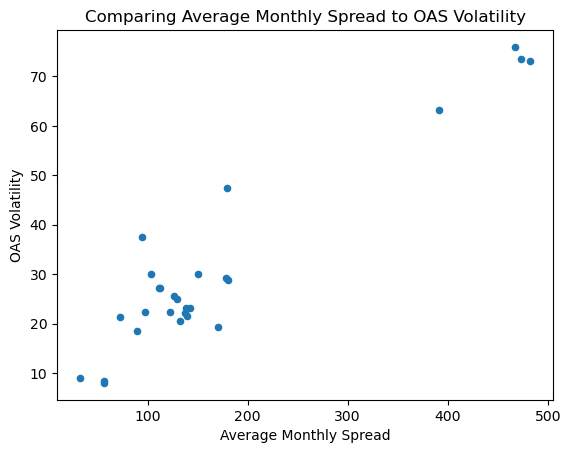

In [33]:
(df_spread_vol
    .merge(right = df_avg_spread, how = "inner", on = ["security"])
    .plot(
        kind   = "scatter", 
        x      = "avg_spread", 
        y      = "spread_vol",
        xlabel = "Average Monthly Spread",
        ylabel = "OAS Volatility",
        title  = "Comparing Average Monthly Spread to OAS Volatility"))

In [34]:
def _get_vol_components(df: pd.DataFrame) -> pd.DataFrame: 

    df_diff = (df
        .diff()
        .dropna())

    ols_model = (sm
        .OLS(
            endog = df_diff.oas,
            exog  = sm.add_constant(df_diff.mean_oas))
        .fit())

    param_dict = ols_model.params.to_dict()
    df_result  = (df_diff
        .assign(
            alpha         = param_dict["const"],
            beta          = param_dict["mean_oas"],
            systemic      = lambda x: x.beta * x.mean_oas,
            idiosyncratic = lambda x: (x.oas - x.alpha) - x.beta * x.mean_oas))

    df_out = (df_result
        [["oas", "systemic", "idiosyncratic"]]
        .agg("std")
        .to_frame(name = "std_val")
        .T
        .assign(
            alpha   = param_dict["const"],
            beta    = param_dict["mean_oas"],
            avg_oas = df.oas.mean()))

    return df_out
    
df_vol_comp = (df_monthly
    .drop(columns = ["security"])
    .groupby("date")
    .agg("mean")
    .rename(columns = {"oas": "mean_oas"})
    .merge(right = df_monthly, how = "inner", on = ["date"])
    .set_index("date")
    .groupby("security")
    .apply(_get_vol_components)
    .reset_index()
    .drop(columns = ["level_1"]))

Text(0.5, 0.98, 'Comparing OAS Level for Volatility Contributions')

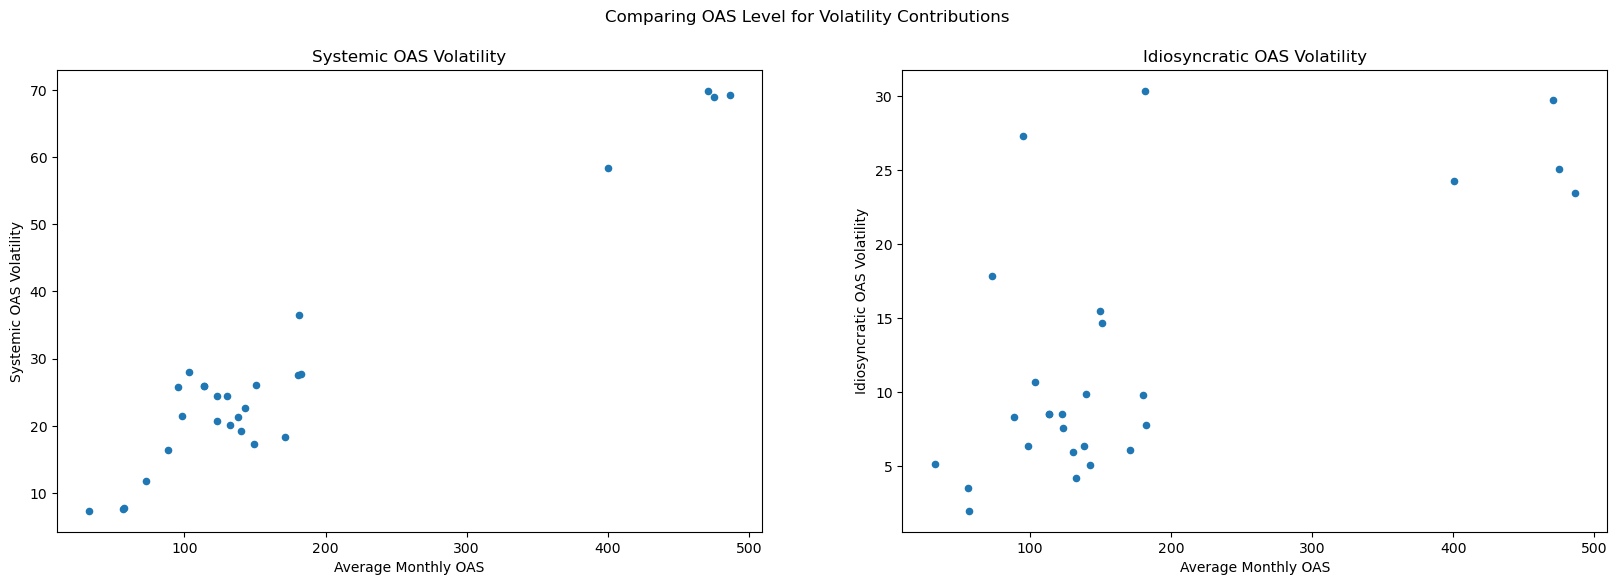

In [35]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_vol_comp
    .plot(
        ax     = axes[0],
        kind   = "scatter", 
        x      = "avg_oas", 
        y      = "systemic",
        ylabel = "Systemic OAS Volatility",
        title  = "Systemic OAS Volatility"))

(df_vol_comp
    .plot(
        ax     = axes[1],
        kind   = "scatter",
        x      = "avg_oas", 
        y      = "idiosyncratic",
        ylabel = "Idiosyncratic OAS Volatility",
        title  = "Idiosyncratic OAS Volatility"))

for ax in axes.flatten():
    ax.set_xlabel("Average Monthly OAS")

fig.suptitle("Comparing OAS Level for Volatility Contributions")